<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
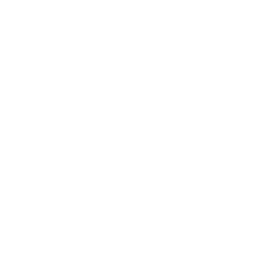
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">병원 부서 자원활용 현황 — 가로 막대 차트</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 의료 / 병원 운영 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>


## 핵심 요약

이 예제는 **PROC GCHART**의 가로 막대 차트(HBAR)를 사용해 2026년 1분기 여섯 개 임상 부서의 근무시간을 분석합니다. 부서당 15건씩, 총 **90건의 근무 기록**으로 구성된 합성 인력 로그가 세 가지 관점을 제공합니다: 총 근무시간 순위 막대 차트, 부서별 평균 근무시간, 그리고 각 부서를 직군별·근무조별로 나눈 그룹 HBAR입니다. `SUMVAR=`는 레코드 수를 세는 대신 실제 근무시간을 합산하고, `TYPE=SUM`/`TYPE=MEAN`은 응답 통계량을 전환하며, `DESCENDING`은 부서를 순위화하고, `GROUP=`은 두 번째 차원을 위한 인접 클러스터 막대를 그립니다.

이 출력은 분기별 운영 효율성 검토를 뒷받침합니다: 어느 부서가 가장 많은 인력을 소모하는지, 어느 부서가 가장 긴 근무를 운영하는지, 그리고 상시 중증도 병동과 주간 중심 서비스 간에 주간/저녁/야간 인력 배치 패턴이 어떻게 다른지를 드러냅니다.

## 데이터 소스

| 소스 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.STAFFING_LOG | 근무시간을 포함한 개별 근무 기록 | 90 |
| WORK.DEPT_SUMMARY | 부서별 합계 및 평균 근무시간 | 6 |

---

In [1]:
/* --------------------------------------------------------
   합성 병원 인력 근무 로그를 생성합니다.
   2026년 1분기: 임상 부서 6개, 직군 4개,
   근무조 3개. 부서당 15건의 근무 기록
   (총 90건)으로 구성해 전체 부서 명단이 모두 보이도록 합니다.
   -------------------------------------------------------- */
데이터 work.staffing_log;
    호출 streaminit(20260601);
    길이 department $24 resource_type $20 shift $8;

    /* 직군 비중 (간호 중심의 임상 인력 배치) */
    배열 resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* 기본 근무조 비중, 상시 병동은 야간 쪽으로 기울어짐 */
    배열 shfw[3] _temporary_ (0.45 0.30 0.25);
    배열 nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    반복 di = 1 까지 6;
        만약 di = 1 이면 department = '응급실';
        아니면 만약 di = 2 이면 department = '외과';
        아니면 만약 di = 3 이면 department = '중환자실';
        아니면 만약 di = 4 이면 department = '소아과';
        아니면 만약 di = 5 이면 department = '종양내과';
        아니면 department = '산부인과';

        반복 rec = 1 까지 15;

            /* 가중 추출로 직군 결정 */
            u = rand('uniform'); cum = 0;
            반복 r = 1 까지 4;
                cum + resw[r];
                만약 u <= cum 이면 반복;
                    만약 r = 1 이면 resource_type = '간호';
                    아니면 만약 r = 2 이면 resource_type = '의사';
                    아니면 만약 r = 3 이면 resource_type = '보건전문직';
                    아니면 resource_type = '지원인력';
                    탈출;
                종료;
            종료;

            /* 부서별 야간 편중을 반영한 근무조 결정 */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            만약 u <= w1 이면 shift = '주간';
            아니면 만약 u <= w1 + w2 이면 shift = '저녁';
            아니면 shift = '야간';

            /* 근무시간: 의사와 외과는 더 긴 근무 */
            BASE = 8;
            만약 resource_type = '의사' 이면 BASE = BASE + 1.5;
            만약 department = '외과' 이면 BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            만약 hours_worked < 4 이면 hours_worked = 4;

            출력;
        종료;
    종료;
    유지 department resource_type shift hours_worked;
    라벨 department = '부서' resource_type = '직군' shift = '근무조'
          hours_worked = '근무시간(시간)';
실행;



NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


In [2]:
/* --------------------------------------------------------
   부서별 합계와 평균 근무시간을
   총 근무시간 기준으로 순위화합니다.
   -------------------------------------------------------- */
처리 SQL;
    CREATE TABLE work.dept_summary AS
    선택 department,
           sum(hours_worked)  AS total_hours   형식=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  형식=6.2
    FROM work.staffing_log
    GROUP 기준 department
    ORDER 기준 total_hours DESC;
QUIT;

처리 인쇄 데이터=work.dept_summary noobs 라벨;
    라벨 total_hours   = '총 근무시간'
          shift_count   = '근무 횟수'
          avg_shift_hrs = '평균 근무시간(시간)';
    제목 '부서별 인력 운영 요약 - 2026년 1분기';
실행;
제목;


                                                부서별 인력 운영 요약 - 2026년 1분기                                                

          부서            총 근무시간          근무 횟수                  평균 근무시간(시간)
외과                      136.25             15                         9.08
중환자실                    128.50             15                         8.57
산부인과                    127.75             15                         8.52
소아과                     124.75             15                         8.32
종양내과                    123.75             15                         8.25
응급실                     119.25             15                         7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                                        부서별 근무시간                                                        

                                                  The MEANS Procedure

                                 Analysis Variable : hours_worked 근무시간(시간)

        부서                      Sum           Mean          N Obs
        ---------------------------------------------------------
        산부인과                 127.75           8.52             15
        소아과                  124.75           8.32             15
        외과                   136.25           9.08             15
        응급실                  119.25           7.95             15
        종양내과                 123.75           8.25             15
        중환자실                 128.50           8.57             15
        ---------------------------------------------------------

                                                       부서별 근무조 분포                                                       

              


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


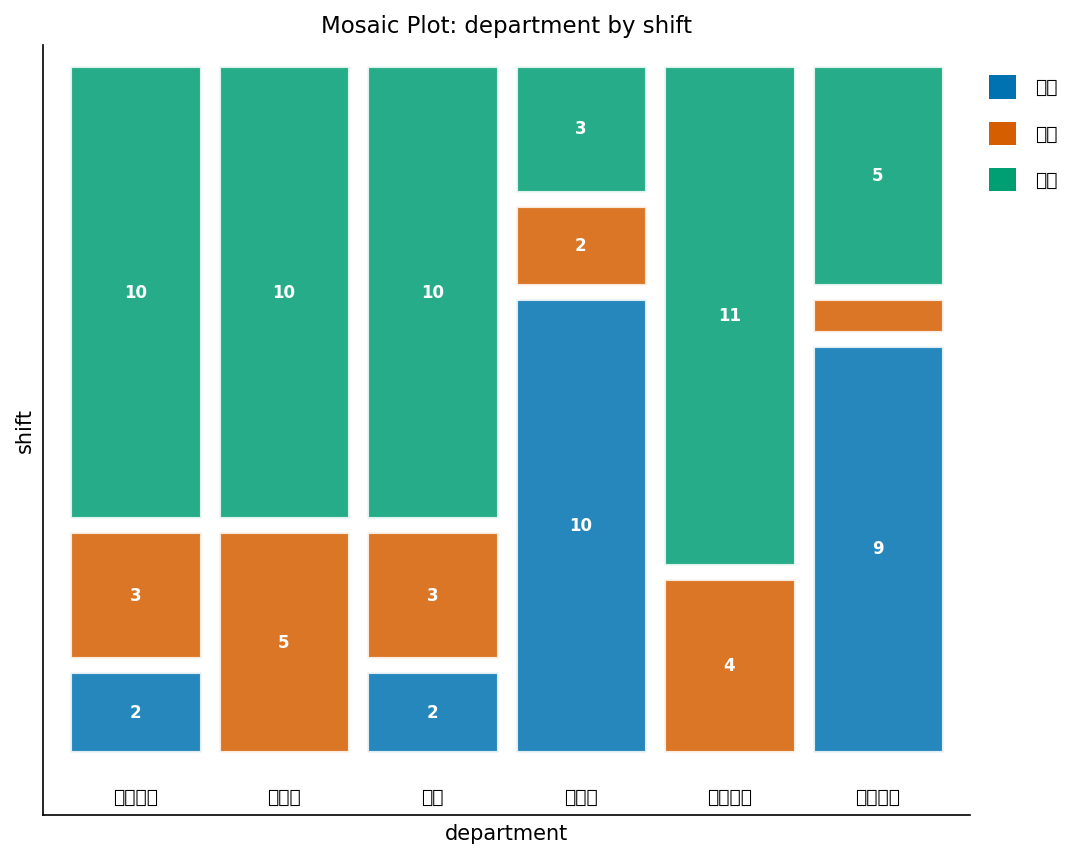

In [3]:
/* --------------------------------------------------------
   기준 표: 부서별 근무시간과 부서별
   주간/저녁/야간 근무조 분포.
   -------------------------------------------------------- */
처리 평균 데이터=work.staffing_log sum mean n maxdec=2;
    분류 department;
    변수 hours_worked;
    라벨 department = '부서' hours_worked = '근무시간(시간)';
    제목 '부서별 근무시간';
실행;

처리 빈도 데이터=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    라벨 department = '부서' shift = '근무조';
    제목 '부서별 근무조 분포';
실행;
제목;


---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


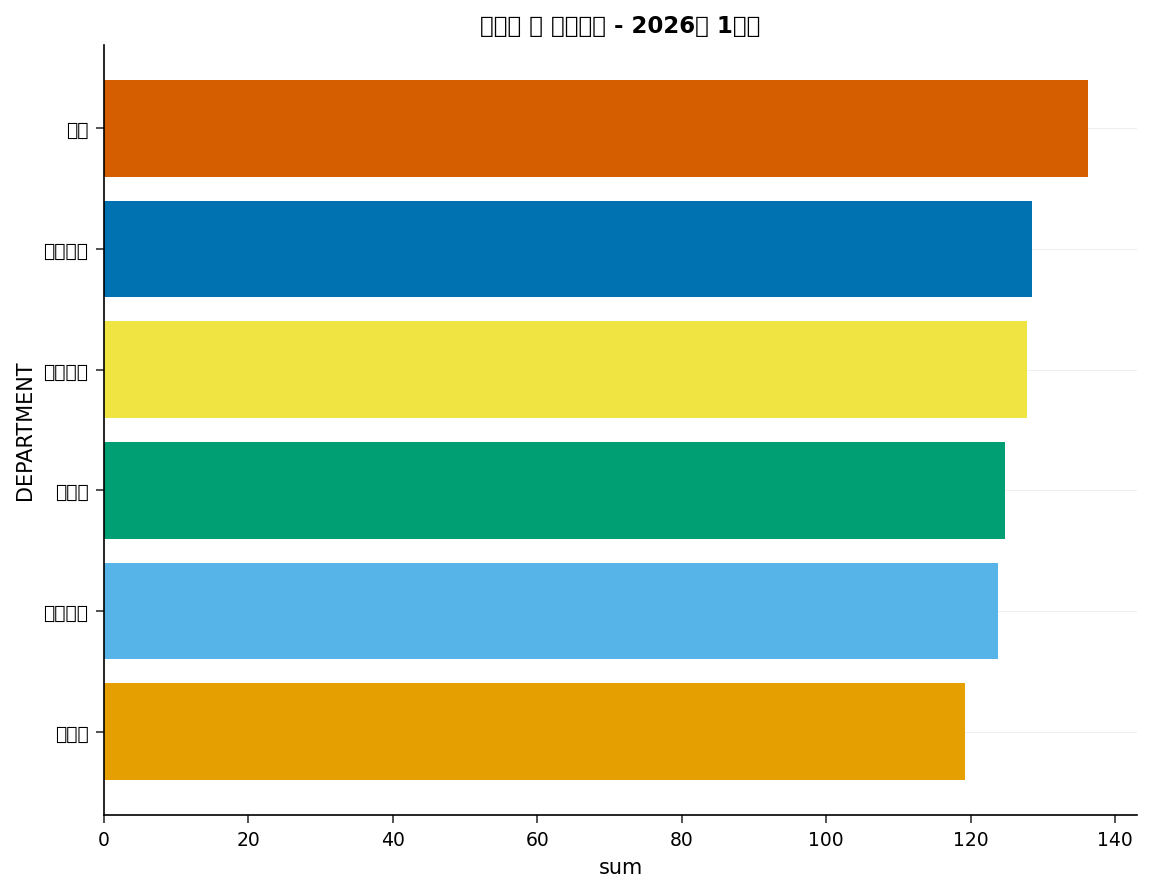

In [4]:
/* --------------------------------------------------------
   개요 HBAR: 부서별 총 근무시간.
   SUMVAR=는 근무시간을 합산하고 DESCENDING은 막대를 순위화합니다.
   -------------------------------------------------------- */
처리 GCHART 데이터=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      DESCENDING;
    라벨 department = '부서' hours_worked = '근무시간(시간)';
    제목 '부서별 총 근무시간 - 2026년 1분기';
실행;
QUIT;
제목;


### 직군별로 각 부서 나누기

`GROUP=`은 모든 부서에 대해 인접한 가로 막대의 클러스터를 그리며, 직군마다 막대 하나씩 배정합니다. `SUMVAR=hours_worked`가 적용되므로 각 막대는 레코드 수가 아니라 누적 근무시간을 측정하며, 이를 통해 차트는 간호·의사·보건전문직·지원인력 근무시간이 각 부서 *내에서* 어떻게 비교되는지 보여줍니다.

In [5]:
/* --------------------------------------------------------
   PATTERN 문: 조율된 4색 팔레트
   직군 서브그룹마다 패턴 하나씩
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* 간호 — 진한 파랑 */
pattern2 VALUE=solid color=cx28A745;   /* 의사 — 초록 */
pattern3 VALUE=solid color=cxE8650A;   /* 보건전문직 — 호박색 */
pattern4 VALUE=solid color=cx6C757D;   /* 지원인력 — 회색 */


                                                      직군별 부서 근무시간                                                       


자료: 인력관리시스템 | 보고 기간: 2026년 1월-3월



NOTE: Option TITLE changed to 직군별 부서 근무시간.
NOTE: Option FOOTNOTE changed to 자료: 인력관리시스템 | 보고 기간: 2026년 1월-3월.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


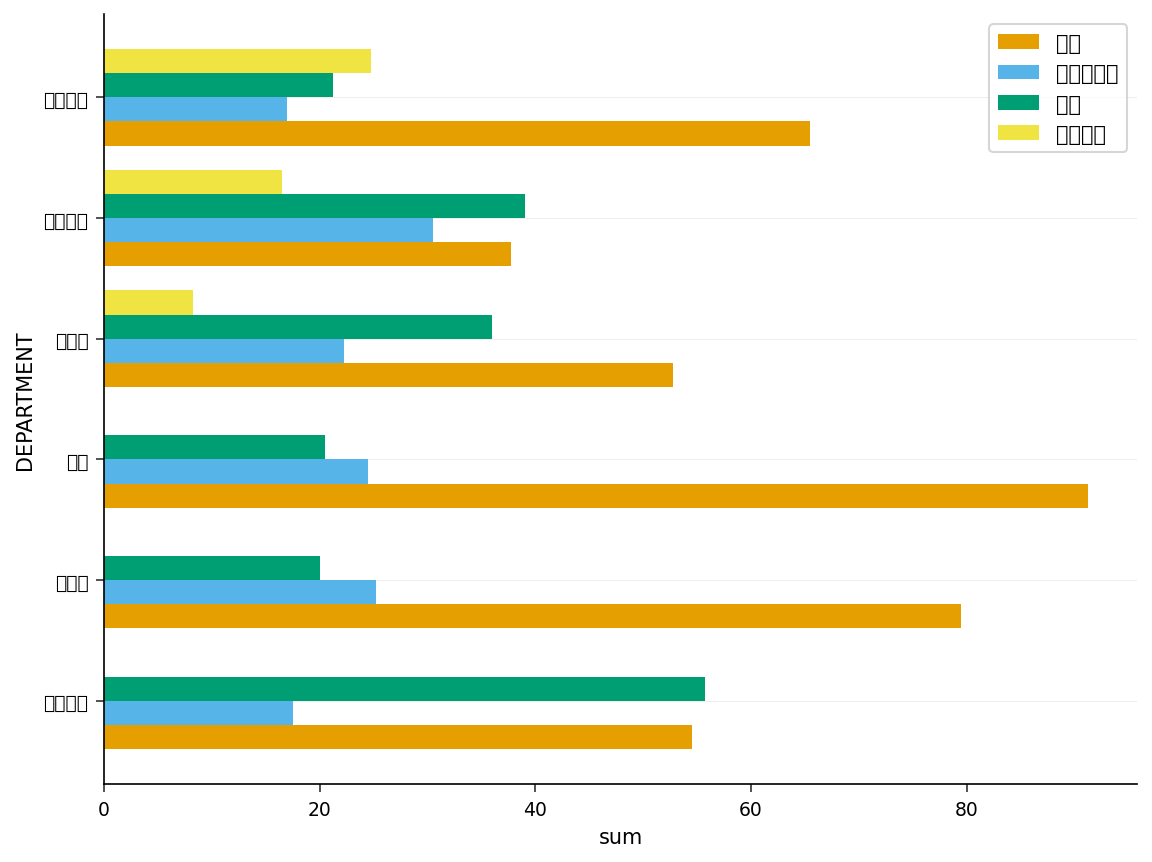

In [6]:
/* --------------------------------------------------------
   직군(GROUP=)별로 그룹화한 HBAR.
   각 부서가 직군별 막대 클러스터가 되며 -- 누적 근무시간으로
   측정됩니다.
   -------------------------------------------------------- */
제목 '직군별 부서 근무시간';
footnote JUSTIFY=LEFT
    '자료: 인력관리시스템 | 보고 기간: 2026년 1월-3월';

처리 GCHART 데이터=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
    라벨 department = '부서' resource_type = '직군' hours_worked = '근무시간(시간)';
실행;
QUIT;

제목; footnote;


                                                      근무조별 부서 근무시간                                                      


그룹 막대는 부서별 주간/저녁/야간 기여도를 구분합니다



NOTE: Option TITLE changed to 근무조별 부서 근무시간.
NOTE: Option FOOTNOTE changed to 그룹 막대는 부서별 주간/저녁/야간 기여도를 구분합니다.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


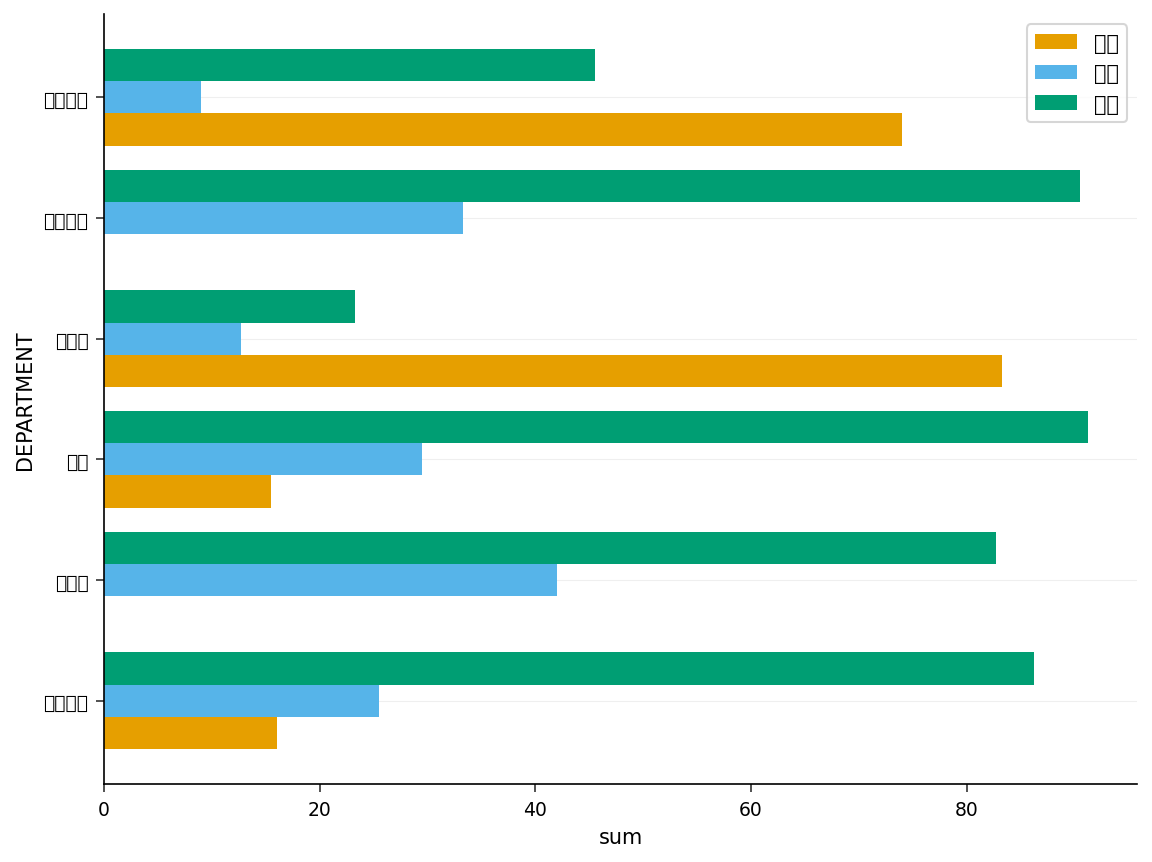

In [7]:
/* --------------------------------------------------------
   근무조(GROUP=)별로 그룹화한 HBAR.
   부서별로 주간/저녁/야간 근무시간을 구분합니다
   -- 24시간 상시 병동을 부각합니다.
   -------------------------------------------------------- */
제목 '근무조별 부서 근무시간';
footnote JUSTIFY=LEFT
    '그룹 막대는 부서별 주간/저녁/야간 기여도를 구분합니다';

처리 GCHART 데이터=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
    라벨 department = '부서' shift = '근무조' hours_worked = '근무시간(시간)';
실행;
QUIT;

제목; footnote;



NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


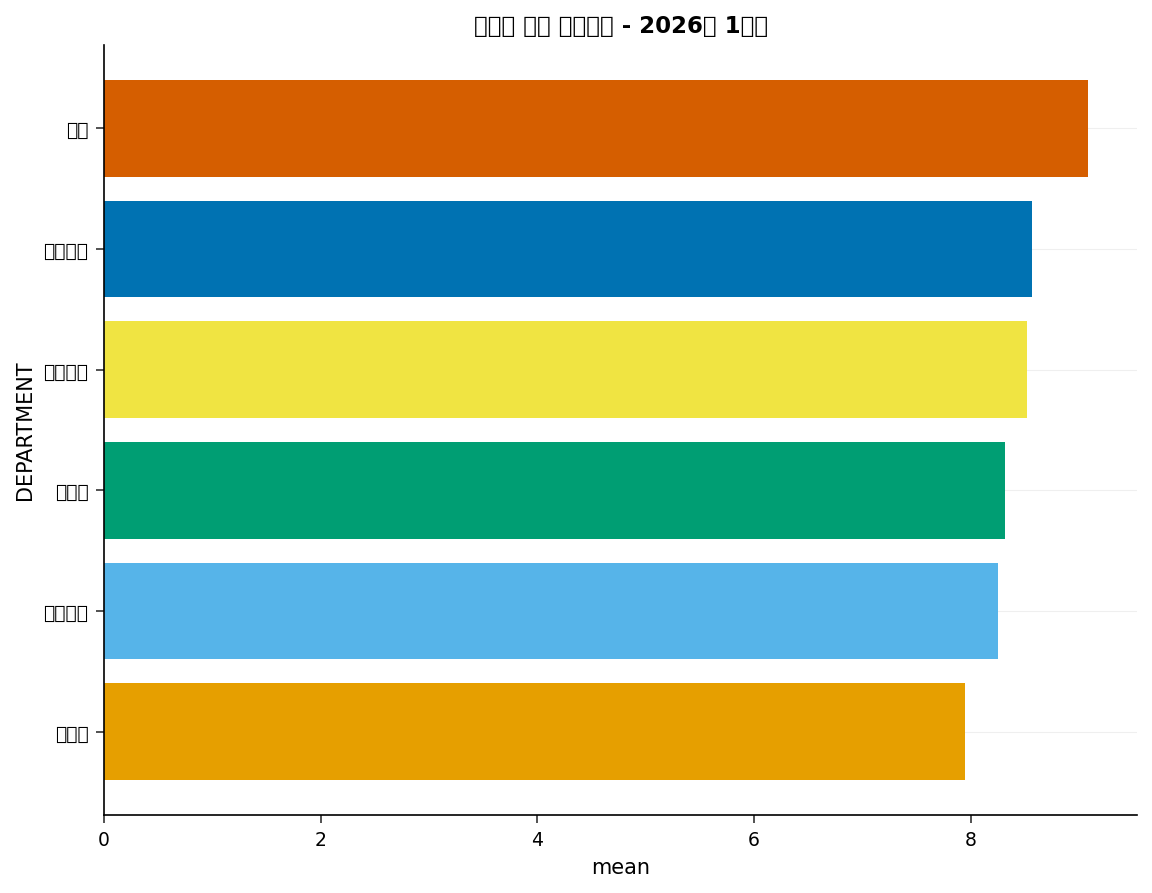

In [8]:
/* --------------------------------------------------------
   부서별 평균 근무시간(TYPE=MEAN).
   전체 물량과 무관하게 부서가 긴 근무를 운영하는지
   짧은 근무를 여러 번 운영하는지를 보여줍니다.
   -------------------------------------------------------- */
처리 GCHART 데이터=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      DESCENDING;
    라벨 department = '부서' hours_worked = '근무시간(시간)';
    제목 '부서별 평균 근무시간 - 2026년 1분기';
실행;
QUIT;
제목;


---

### 결과 해석

90건의 근무 기록에서 총 근무시간은 **119.25**시간(응급실)에서 **136.25**시간(외과) 사이의 좁은 범위에 분포합니다. 이는 이번 기간에 모든 부서가 동일하게 15건의 근무를 담당하기 때문이며, 따라서 이 순위는 근무 건수가 아니라 **근무 길이**를 반영합니다. 외과는 근무당 평균 **9.08시간**으로 총 근무시간 차트와 평균 근무시간 차트 모두에서 1위를 차지하는데, 이는 더 긴 수술 케이스와 그에 필요한 의사 중심의 인력 배치와 일치합니다. 응급실은 가장 바쁜 부서 중 하나임에도 근무시간(평균 **7.95**시간)에서는 최하위인데, 이는 업무가 더 짧고 회전율이 높은 근무로 처리되기 때문입니다.

근무조별 그룹 HBAR와 모자이크 패널은 운영상 중요한 이야기를 전합니다. **응급실과 중환자실은 야간 중심**입니다 — 각각 15건 중 10건과 9건의 근무가 야간에 배정됩니다 — 반면 **종양내과와 소아과는 야간 근무가 전혀 없고** 주간 커버리지에 집중합니다(각각 11건과 10건의 주간 근무). 이 구분은 실제 병원 인력 배치를 그대로 반영합니다: 상시 중증도 병동은 24시간 운영되는 반면, 종양내과 주입치료와 일반 소아과는 주간 중심 서비스입니다. 직군별 패널은 모든 부서에서 **간호 중심의 구성**을 확인해 주며, 의사와 보건전문직 근무시간이 그다음 비중을 차지합니다.

2분기 인력 배치 검토를 위해서는 응급실과 중환자실의 야간 근무 집중이 주목해야 할 항목입니다: 이곳에서 야간수당과 피로관리 비용이 누적되며, 근무 로테이션 변경이 예산에 가장 큰 영향을 미치는 지점입니다.

---

In [9]:
/* --------------------------------------------------------
   인력 계획 시스템을 위해 부서 요약을 내보냅니다.
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
실행;



NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Jenner 제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>